# LATUPNet + 3D Wavelet Preprocessing for BraTS2020

This notebook runs directly on Kaggle with the BraTS2020 dataset attached.

Goal:
- Keep the current project direction: **LATUPNet for 3D brain tumor segmentation**.
- Add **3D wavelet texture features** as preprocessing / feature augmentation.
- Train a new **9-channel LATUPNet**:
  - 3 MRI channels: `T1ce`, `T2`, `FLAIR`
  - 6 wavelet channels: 3 source maps x 2 wavelet levels
- Log training, validation metrics, visual overlays, checkpoints, and prediction artifacts with **Weights & Biases**.

Important: this notebook does **not** reuse the old 3-channel checkpoint. Because the input changes from 3 to 9 channels, the model must be trained again.


In [1]:
# Cell 1 - Install/check required packages for Kaggle
import importlib.util
import subprocess
import sys

required_packages = {
    "nibabel": "nibabel",
    "pywt": "PyWavelets",
    "skimage": "scikit-image",
    "wandb": "wandb",
    "tqdm": "tqdm",
}

missing = [pkg for module, pkg in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are already available.")


All required packages are already available.


In [2]:
# Cell 2 - Imports and reproducibility
import os
import json
import time
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import nibabel as nib
import pywt
import matplotlib.pyplot as plt

from scipy.ndimage import zoom, binary_erosion, generate_binary_structure, distance_transform_edt
from skimage.transform import resize
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import wandb

warnings.filterwarnings("ignore")


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(42)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


c:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.11.0+cu128
CUDA available: True


## Experiment Configuration

The notebook auto-detects BraTS2020 cases from `/kaggle/input`.

Default input contract:

| Group | Channels |
|---|---|
| MRI | `T1ce`, `T2`, `FLAIR` |
| Wavelet | 6 maps from `T1ce`, `T1ce - FLAIR`, `T2 - T1ce` |
| Final model input | `9 x 128 x 128 x 128` |

BraTS labels:

| Label | Meaning |
|---:|---|
| 0 | Background |
| 1 | NCR/NET |
| 2 | ED |
| 4 | ET |


In [3]:
# Cell 3 - Global configuration
SEED = 42
DATA_ROOT = Path(
    "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
).resolve()

WORK_DIR = Path("outputs").resolve()
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("WORK_DIR:", WORK_DIR)

PROJECT_NAME = "BraTS2020_Segmentation"
EXPERIMENT_TAG = "region3_sigmoid_priority1"
RUN_NAME = f"LATUPNet_9ch_sym8_L2_128_{EXPERIMENT_TAG}"
WANDB_ENTITY = None  # Optional: set to your W&B username/team, e.g. "your_entity"

INPUT_MODALITIES = ["t1ce", "t2", "flair"]
PATCH_SIZE = (128, 128, 128)
TARGET_SPACING = (1.0, 1.0, 1.0)

# Default is minmax to stay close to the existing LATUPNet project contract.
# Change to "zscore" if you want a z-score preprocessing ablation.
NORMALIZATION = "minmax"  # "minmax" or "zscore"
USE_PERCENTILE_CLIP = True
P_LOW, P_HIGH = 1.0, 99.0

WAVELET_NAME = "sym8"
WAVELET_LEVEL = 2
WAVELET_MODE = "symmetric"
WAVELET_SOURCE_NAMES = ["t1ce", "t1ce_minus_flair", "t2_minus_t1ce"]
NUM_MRI_CHANNELS = 3
NUM_WAVELET_CHANNELS = len(WAVELET_SOURCE_NAMES) * WAVELET_LEVEL
INPUT_CHANNELS = NUM_MRI_CHANNELS + NUM_WAVELET_CHANNELS
NUM_CLASSES = 3

VAL_RATIO = 0.20
EPOCHS = 100
BATCH_SIZE = 2
NUM_WORKERS = 2
LR = 1e-4
SCHEDULER_ETA_MIN = 1e-6
WEIGHT_DECAY = 1e-5
USE_AMP = True
GRAD_CLIP_NORM = 1.0
ET_LOSS_WEIGHT_MULTIPLIER = 1.1

# Set these to small numbers for a fast smoke test, then change back to None for real training.
MAX_TRAIN_CASES = None
MAX_VAL_CASES = None

COMPUTE_HD95 = False  # HD95 is expensive. Enable for final evaluation if Kaggle runtime allows it.
VIS_EVERY_N_EPOCHS = 10
NUM_SAMPLE_PREDICTIONS = 3

BASELINE_30EP_VAL_MEAN_DICE = 0.82553
TARGET_VAL_DICE_ET = 0.73

# Cache validation preprocessing by default. Set CACHE_SCOPE = "all" only if Kaggle disk has enough free space.
CACHE_PREPROCESSED = True
CACHE_SCOPE = "val"  # "none", "val", or "all"
CACHE_DIR = WORK_DIR / f"preprocess_cache_{EXPERIMENT_TAG}"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = WORK_DIR / f"best_latupnet_wavelet_{EXPERIMENT_TAG}.pth"
LAST_CHECKPOINT_PATH = WORK_DIR / f"last_latupnet_wavelet_{EXPERIMENT_TAG}.pth"
RESUME_FROM_LAST = False
SUMMARY_CSV_PATH = WORK_DIR / f"training_summary_{EXPERIMENT_TAG}.csv"
PRED_DIR = WORK_DIR / f"sample_predictions_{EXPERIMENT_TAG}"
PRED_DIR.mkdir(parents=True, exist_ok=True)

WT_THRESHOLD = 0.5
TC_THRESHOLD = 0.5
ET_THRESHOLD = 0.5

CONFIG = {
    "seed": SEED,
    "experiment_tag": EXPERIMENT_TAG,
    "run_name": RUN_NAME,
    "wandb_entity": WANDB_ENTITY,
    "input_modalities": INPUT_MODALITIES,
    "patch_size": PATCH_SIZE,
    "target_spacing": TARGET_SPACING,
    "normalization": NORMALIZATION,
    "use_percentile_clip": USE_PERCENTILE_CLIP,
    "wavelet_name": WAVELET_NAME,
    "wavelet_level": WAVELET_LEVEL,
    "wavelet_mode": WAVELET_MODE,
    "wavelet_sources": WAVELET_SOURCE_NAMES,
    "num_mri_channels": NUM_MRI_CHANNELS,
    "num_wavelet_channels": NUM_WAVELET_CHANNELS,
    "input_channels": INPUT_CHANNELS,
    "num_classes": NUM_CLASSES,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "scheduler_eta_min": SCHEDULER_ETA_MIN,
    "weight_decay": WEIGHT_DECAY,
    "use_amp": USE_AMP,
    "et_loss_weight_multiplier": ET_LOSS_WEIGHT_MULTIPLIER,
    "baseline_30ep_val_mean_dice": BASELINE_30EP_VAL_MEAN_DICE,
    "target_val_dice_et": TARGET_VAL_DICE_ET,
    "cache_preprocessed": CACHE_PREPROCESSED,
    "cache_scope": CACHE_SCOPE,
    "cache_dir": str(CACHE_DIR),
    "resume_from_last": RESUME_FROM_LAST,
    "output_representation": "WT_TC_ET_regions",
    "output_activation": "sigmoid",
    "wt_threshold": WT_THRESHOLD,
    "tc_threshold": TC_THRESHOLD,
    "et_threshold": ET_THRESHOLD,
}

print(json.dumps(CONFIG, indent=2, default=str))
assert INPUT_CHANNELS == 9, f"Expected 9 input channels, got {INPUT_CHANNELS}"


DATA_ROOT: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\BraTS2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
DATA_ROOT exists: True
WORK_DIR: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\outputs
{
  "seed": 42,
  "experiment_tag": "region3_sigmoid_priority1",
  "run_name": "LATUPNet_9ch_sym8_L2_128_region3_sigmoid_priority1",
  "wandb_entity": null,
  "input_modalities": [
    "t1ce",
    "t2",
    "flair"
  ],
  "patch_size": [
    128,
    128,
    128
  ],
  "target_spacing": [
    1.0,
    1.0,
    1.0
  ],
  "normalization": "minmax",
  "use_percentile_clip": true,
  "wavelet_name": "sym8",
  "wavelet_level": 2,
  "wavelet_mode": "symmetric",
  "wavelet_sources": [
    "t1ce",
    "t1ce_minus_flair",
    "t2_minus_t1ce"
  ],
  "num_mri_channels": 3,
  "num_wavelet_channels": 6,
  "input_channels": 9,
  "num_classes": 3,
  "epochs": 100,
  "batch_size": 2,
  "lr": 0.0001,
  "scheduler_eta_

In [4]:
# Cell 4 - Weights & Biases setup
# Recommended on Kaggle: Add a secret named WANDB_API_KEY.
# If the secret is missing, this notebook runs W&B in offline mode.
import os
import wandb
from dotenv import load_dotenv

load_dotenv()

wandb_mode = "online"

try:
    wandb_key = os.getenv("WANDB_API_KEY")

    if not wandb_key:
        raise ValueError("WANDB_API_KEY was not found in environment or .env file")

    wandb.login(
        key=wandb_key,
        relogin=True,
    )

    print("W&B login: online")

except Exception as exc:
    os.environ["WANDB_MODE"] = "offline"
    wandb_mode = "offline"

    print("W&B login skipped, using offline mode:", exc)


run = wandb.init(
    project=PROJECT_NAME,
    name=RUN_NAME,
    config=CONFIG,
    mode=wandb_mode,
    resume="allow",
)

wandb.define_metric("epoch")
wandb.define_metric("train/*", step_metric="epoch")
wandb.define_metric("val/*", step_metric="epoch")
wandb.define_metric("time/*", step_metric="epoch")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\ezycloudx-admin\_netrc
wandb: Currently logged in as: nlhnhenry (nlhnhenry-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login: online


## Data Discovery

The dataset is expected to be attached to the Kaggle notebook.
This cell searches recursively under `/kaggle/input` for BraTS training cases containing:

- `*_t1ce.nii` or `*_t1ce.nii.gz`
- `*_t2.nii` or `*_t2.nii.gz`
- `*_flair.nii` or `*_flair.nii.gz`
- `*_seg.nii` or `*_seg.nii.gz`


In [5]:
# Cell 5 - Case discovery and split
def find_modality_file(case_dir: Path, modality: str) -> Optional[Path]:
    patterns = [
        f"*_{modality}.nii",
        f"*_{modality}.nii.gz",
        f"*{modality}.nii",
        f"*{modality}.nii.gz",
    ]
    matches = []
    for pattern in patterns:
        matches.extend(case_dir.glob(pattern))
    matches = sorted(set(matches))
    return matches[0] if matches else None


def discover_brats_cases(root: Path) -> List[Dict[str, str]]:
    case_records = []
    seg_files = sorted(root.rglob("*_seg.nii*"))
    seen_dirs = set()
    for seg_path in seg_files:
        case_dir = seg_path.parent
        if case_dir in seen_dirs:
            continue
        seen_dirs.add(case_dir)

        record = {"case_id": case_dir.name, "case_dir": str(case_dir), "seg": str(seg_path)}
        ok = True
        for modality in INPUT_MODALITIES:
            f = find_modality_file(case_dir, modality)
            if f is None:
                ok = False
                break
            record[modality] = str(f)
        if ok:
            case_records.append(record)
    return case_records


all_cases = discover_brats_cases(DATA_ROOT)
print(f"Found {len(all_cases)} training cases with segmentation masks.")
if len(all_cases) == 0:
    raise RuntimeError(
        "No BraTS cases were found. Attach Kaggle dataset "
        "awsaf49/brats20-dataset-training-validation to this notebook."
    )

rng = random.Random(SEED)
rng.shuffle(all_cases)
val_count = max(1, int(len(all_cases) * VAL_RATIO))
val_cases = all_cases[:val_count]
train_cases = all_cases[val_count:]

if MAX_TRAIN_CASES is not None:
    train_cases = train_cases[:MAX_TRAIN_CASES]
if MAX_VAL_CASES is not None:
    val_cases = val_cases[:MAX_VAL_CASES]

print(f"Train cases: {len(train_cases)}")
print(f"Val cases:   {len(val_cases)}")
print("Example case:", train_cases[0])

Found 368 training cases with segmentation masks.
Train cases: 295
Val cases:   73
Example case: {'case_id': 'BraTS20_Training_020', 'case_dir': 'C:\\Users\\ezycloudx-admin\\Downloads\\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\\BraTS2020\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_020', 'seg': 'C:\\Users\\ezycloudx-admin\\Downloads\\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\\BraTS2020\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_020\\BraTS20_Training_020_seg.nii', 't1ce': 'C:\\Users\\ezycloudx-admin\\Downloads\\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\\BraTS2020\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_020\\BraTS20_Training_020_t1ce.nii', 't2': 'C:\\Users\\ezycloudx-admin\\Downloads\\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\\BraTS2020\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_020\\BraTS20_Training_020_t2.nii', 'flair': 'C:\\Us

## Preprocessing + Wavelet Feature Extraction

Pipeline per patient:

1. Load `T1ce`, `T2`, `FLAIR`, `seg` NIfTI files.
2. Replace `NaN/Inf` values.
3. Verify geometry consistency.
4. Center crop/pad to `128 x 128 x 128`.
5. Normalize each MRI modality inside the brain mask, while keeping background `0`.
6. Build 3 source maps:
   - `T1ce`
   - `T1ce - FLAIR`
   - `T2 - T1ce`
7. Apply 3D wavelet decomposition with `sym8`, level `2`.
8. Convert detail subbands into 2 energy maps per source.
9. Stack final input tensor: `(9, 128, 128, 128)`.


In [6]:
# Cell 6 - Preprocessing and wavelet utilities
def load_nifti(path: str, dtype=np.float32):
    img = nib.load(str(path))
    arr = img.get_fdata(dtype=np.float32).astype(dtype, copy=False)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr, img


def check_same_geometry(images: Dict[str, nib.Nifti1Image], case_id: str):
    shapes = {k: img.shape[:3] for k, img in images.items()}
    if len(set(shapes.values())) != 1:
        raise ValueError(f"{case_id}: modality shape mismatch: {shapes}")

    ref_affine = next(iter(images.values())).affine
    for name, img in images.items():
        if not np.allclose(ref_affine, img.affine, atol=1e-3):
            print(f"Warning: {case_id} affine mismatch in {name}")


def resample_if_needed(volume: np.ndarray, spacing: Tuple[float, float, float], order: int):
    spacing = np.asarray(spacing, dtype=np.float32)
    target = np.asarray(TARGET_SPACING, dtype=np.float32)
    if np.allclose(spacing, target, atol=1e-3):
        return volume
    new_shape = np.round(np.asarray(volume.shape) * spacing / target).astype(int)
    factors = new_shape / np.asarray(volume.shape)
    return zoom(volume, zoom=factors, order=order).astype(volume.dtype, copy=False)


def center_crop_pad_3d(volume: np.ndarray, target_shape=PATCH_SIZE, pad_value=0, return_meta=False):
    target_shape = tuple(int(x) for x in target_shape)
    src_shape = tuple(int(x) for x in volume.shape)
    output = np.full(target_shape, pad_value, dtype=volume.dtype)

    src_slices = []
    dst_slices = []
    for src_len, dst_len in zip(src_shape, target_shape):
        if src_len >= dst_len:
            src_start = (src_len - dst_len) // 2
            src_end = src_start + dst_len
            dst_start = 0
            dst_end = dst_len
        else:
            src_start = 0
            src_end = src_len
            dst_start = (dst_len - src_len) // 2
            dst_end = dst_start + src_len
        src_slices.append(slice(src_start, src_end))
        dst_slices.append(slice(dst_start, dst_end))

    src_slices = tuple(src_slices)
    dst_slices = tuple(dst_slices)
    output[dst_slices] = volume[src_slices]

    if return_meta:
        return output, {
            "original_shape": src_shape,
            "target_shape": target_shape,
            "src_slices": src_slices,
            "dst_slices": dst_slices,
        }
    return output


def inverse_center_crop_pad_3d(cropped: np.ndarray, meta: Dict, pad_value=0):
    output = np.full(meta["original_shape"], pad_value, dtype=cropped.dtype)
    output[meta["src_slices"]] = cropped[meta["dst_slices"]]
    return output


def normalize_in_brain(volume: np.ndarray, brain_mask: np.ndarray, method: str = NORMALIZATION):
    volume = volume.astype(np.float32, copy=True)
    output = np.zeros_like(volume, dtype=np.float32)
    mask = brain_mask & np.isfinite(volume)
    if mask.sum() == 0:
        return output

    values = volume[mask]
    if USE_PERCENTILE_CLIP:
        lo, hi = np.percentile(values, [P_LOW, P_HIGH])
        volume = np.clip(volume, lo, hi)
        values = volume[mask]

    if method == "zscore":
        mean = float(values.mean())
        std = float(values.std())
        if std < 1e-6:
            return output
        output[mask] = (volume[mask] - mean) / std
    elif method == "minmax":
        vmin = float(values.min())
        vmax = float(values.max())
        if vmax - vmin < 1e-6:
            return output
        output[mask] = (volume[mask] - vmin) / (vmax - vmin)
    else:
        raise ValueError(f"Unknown normalization method: {method}")

    output[~brain_mask] = 0.0
    return output.astype(np.float32)


def resize_to_shape(volume: np.ndarray, target_shape=PATCH_SIZE):
    if tuple(volume.shape) == tuple(target_shape):
        return volume.astype(np.float32, copy=False)
    return resize(
        volume,
        output_shape=target_shape,
        order=1,
        mode="reflect",
        anti_aliasing=False,
        preserve_range=True,
    ).astype(np.float32)


def wavelet_energy_maps(source: np.ndarray, brain_mask: np.ndarray) -> List[np.ndarray]:
    coeffs = pywt.wavedecn(
        source.astype(np.float32),
        wavelet=WAVELET_NAME,
        mode=WAVELET_MODE,
        level=WAVELET_LEVEL,
        axes=(0, 1, 2),
    )

    detail_coeffs = coeffs[1:]
    maps = []
    for detail in reversed(detail_coeffs):
        energy = None
        for subband in detail.values():
            component = np.square(np.abs(subband).astype(np.float32))
            energy = component if energy is None else energy + component
        energy = np.sqrt(energy + 1e-8)
        energy = resize_to_shape(energy, PATCH_SIZE)
        energy = normalize_in_brain(energy, brain_mask, method=NORMALIZATION)
        maps.append(energy)

    if len(maps) != WAVELET_LEVEL:
        raise RuntimeError(f"Expected {WAVELET_LEVEL} wavelet maps, got {len(maps)}")
    return maps


def preprocess_case(case: Dict[str, str], require_mask=True):
    case_id = case["case_id"]
    modality_arrays = {}
    modality_imgs = {}

    for modality in INPUT_MODALITIES:
        arr, img = load_nifti(case[modality], dtype=np.float32)
        modality_arrays[modality] = arr
        modality_imgs[modality] = img

    if require_mask:
        seg, seg_img = load_nifti(case["seg"], dtype=np.float32)
        seg = seg.astype(np.int16)
        modality_imgs["seg"] = seg_img
    else:
        seg, seg_img = None, None

    check_same_geometry(modality_imgs, case_id)
    ref_img = modality_imgs[INPUT_MODALITIES[0]]
    spacing = tuple(float(x) for x in ref_img.header.get_zooms()[:3])

    cropped_modalities = {}
    crop_meta = None
    for modality, arr in modality_arrays.items():
        arr = resample_if_needed(arr, spacing, order=1)
        if crop_meta is None:
            arr_crop, crop_meta = center_crop_pad_3d(arr, PATCH_SIZE, pad_value=0, return_meta=True)
        else:
            arr_crop = center_crop_pad_3d(arr, PATCH_SIZE, pad_value=0, return_meta=False)
        cropped_modalities[modality] = arr_crop

    if require_mask:
        seg = resample_if_needed(seg, spacing, order=0)
        seg_crop = center_crop_pad_3d(seg, PATCH_SIZE, pad_value=0, return_meta=False).astype(np.int64)
        seg_crop[~np.isin(seg_crop, [0, 1, 2, 4])] = 0
    else:
        seg_crop = None

    brain_mask = np.zeros(PATCH_SIZE, dtype=bool)
    for arr in cropped_modalities.values():
        brain_mask |= arr > 0

    normalized = {}
    for modality, arr in cropped_modalities.items():
        normalized[modality] = normalize_in_brain(arr, brain_mask, method=NORMALIZATION)

    t1ce = normalized["t1ce"]
    t2 = normalized["t2"]
    flair = normalized["flair"]

    wavelet_sources = [t1ce, t1ce - flair, t2 - t1ce]
    wavelet_channels = []
    for source in wavelet_sources:
        wavelet_channels.extend(wavelet_energy_maps(source, brain_mask))

    image = np.stack([t1ce, t2, flair, *wavelet_channels], axis=0).astype(np.float32)
    image[:, ~brain_mask] = 0.0

    if image.shape != (INPUT_CHANNELS, *PATCH_SIZE):
        raise RuntimeError(f"{case_id}: bad image shape {image.shape}")

    return {
        "case_id": case_id,
        "image": image,
        "mask": seg_crop,
        "flair": flair,
        "brain_mask": brain_mask,
        "affine": ref_img.affine,
        "crop_meta": crop_meta,
        "spacing": spacing,
        "original_shape": ref_img.shape[:3],
    }


In [7]:
# Cell 7 - Dataset and DataLoader
def cache_file_for_case(case: Dict[str, str], split_name: str) -> Path:
    safe_id = "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in case["case_id"])
    shape_tag = "x".join(str(x) for x in PATCH_SIZE)
    return CACHE_DIR / f"{split_name}_{safe_id}_{shape_tag}_{WAVELET_NAME}_L{WAVELET_LEVEL}_{NORMALIZATION}.npz"


def should_cache_split(split_name: str) -> bool:
    if not CACHE_PREPROCESSED or CACHE_SCOPE == "none":
        return False
    return CACHE_SCOPE == "all" or CACHE_SCOPE == split_name


from Brats_Dataset.BratsSet import BraTSWaveletDataset


train_ds = BraTSWaveletDataset(train_cases, augment=True, split_name="train")
val_ds = BraTSWaveletDataset(val_cases, augment=False, split_name="val")

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)
val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

sample = train_ds[0]
print("Sample image:", tuple(sample["image"].shape))
print("Sample mask: ", tuple(sample["mask"].shape))
print("Unique labels:", torch.unique(sample["mask"]))
print(f"Preprocessing cache: enabled={CACHE_PREPROCESSED}, scope={CACHE_SCOPE}, dir={CACHE_DIR}")
assert tuple(sample["image"].shape) == (9, 128, 128, 128)
assert tuple(sample["mask"].shape) == (128, 128, 128)


Torch: 2.11.0+cu128
CUDA available: True
DATA_ROOT: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\BraTS2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
DATA_ROOT exists: True
WORK_DIR: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\outputs
{
  "seed": 42,
  "experiment_tag": "region3_sigmoid_priority1",
  "run_name": "LATUPNet_9ch_sym8_L2_128_region3_sigmoid_priority1",
  "wandb_entity": null,
  "input_modalities": [
    "t1ce",
    "t2",
    "flair"
  ],
  "patch_size": [
    128,
    128,
    128
  ],
  "target_spacing": [
    1.0,
    1.0,
    1.0
  ],
  "normalization": "minmax",
  "use_percentile_clip": true,
  "wavelet_name": "sym8",
  "wavelet_level": 2,
  "wavelet_mode": "symmetric",
  "wavelet_sources": [
    "t1ce",
    "t1ce_minus_flair",
    "t2_minus_t1ce"
  ],
  "num_mri_channels": 3,
  "num_wavelet_channels": 6,
  "input_channels": 9,
  "num_classes": 3,
  "epochs": 100,
  "batch_si

## LATUPNet Architecture

This is a self-contained LATUPNet implementation based on the existing project notebook, with one key change:

```python
in_channels = 9
```

The output remains 4 channels:

```text
0 = Background
1 = NCR/NET
2 = ED
3 = ET channel, mapped back to BraTS label 4 during prediction
```


In [8]:
# Cell 8 - LATUPNet model
class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.global_avg_pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _, _ = x.size()
        y = self.global_avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1, 1)
        return x * y.expand_as(x)


class ParallelConvolutionBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.shared_conv = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.LeakyReLU(negative_slope=0.1, inplace=True)
        self.conv1 = nn.Conv3d(out_channels, out_channels, kernel_size=1, padding=0)
        self.conv3 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv3d(out_channels, out_channels, kernel_size=5, padding=2)
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward_with_skip(self, x):
        x_shared = self.relu(self.shared_conv(x))
        path1 = self.pool(self.relu(self.conv1(x_shared)))
        path2 = self.pool(self.relu(self.conv3(x_shared)))
        path3 = self.pool(self.relu(self.conv5(x_shared)))
        pc_out = torch.cat([path1, path2, path3], dim=1)
        return x_shared, pc_out

    def forward(self, x):
        _, pc_out = self.forward_with_skip(x)
        return pc_out


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_se=True, dropout_rate=0.2):
        super().__init__()
        self.se = SqueezeExcitation(in_channels) if use_se else nn.Identity()
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm3d(out_channels, affine=True)
        self.relu = nn.LeakyReLU(negative_slope=0.1, inplace=True)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.InstanceNorm3d(out_channels, affine=True)
        self.dropout = nn.Dropout3d(dropout_rate)
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.se(x)
        x = self.relu(self.norm1(self.conv1(x)))
        x = self.relu(self.norm2(self.conv2(x)))
        x = self.dropout(x)
        skip = x
        x = self.pool(x)
        return x, skip


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, use_se=True, dropout_rate=0.2):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm3d(out_channels, affine=True)
        self.relu = nn.LeakyReLU(negative_slope=0.1, inplace=True)
        self.se = SqueezeExcitation(out_channels) if use_se else nn.Identity()
        self.conv2 = nn.Conv3d(out_channels + skip_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.InstanceNorm3d(out_channels, affine=True)
        self.dropout = nn.Dropout3d(dropout_rate)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = self.relu(self.norm1(self.conv1(x)))
        x = self.se(x)
        if x.shape[2:] != skip.shape[2:]:
            skip = F.interpolate(skip, size=x.shape[2:], mode="trilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.relu(self.norm2(self.conv2(x)))
        x = self.dropout(x)
        return x


class LATUPNet(nn.Module):
    def __init__(self, in_channels=9, num_classes=NUM_CLASSES, use_se=True, dropout_rate=0.2):
        super().__init__()
        self.pc_block = ParallelConvolutionBlock(in_channels, 32)
        self.enc2 = EncoderBlock(96, 64, use_se=use_se, dropout_rate=dropout_rate)
        self.enc3 = EncoderBlock(64, 128, use_se=use_se, dropout_rate=dropout_rate)
        self.bottleneck_se = SqueezeExcitation(128) if use_se else nn.Identity()
        self.dec3 = DecoderBlock(128, 128, 128, use_se=use_se, dropout_rate=dropout_rate)
        self.dec2 = DecoderBlock(128, 64, 64, use_se=use_se, dropout_rate=dropout_rate)
        self.dec1 = DecoderBlock(64, 32, 32, use_se=False, dropout_rate=dropout_rate)
        self.final_conv = nn.Conv3d(32, num_classes, kernel_size=1)
        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv3d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="leaky_relu")
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.InstanceNorm3d):
                if module.weight is not None:
                    nn.init.constant_(module.weight, 1)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

    def forward(self, x):
        skip_pc, x = self.pc_block.forward_with_skip(x)
        x, skip2 = self.enc2(x)
        x, skip3 = self.enc3(x)
        x = self.bottleneck_se(x)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip_pc)
        return self.final_conv(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LATUPNet(in_channels=INPUT_CHANNELS, num_classes=NUM_CLASSES, use_se=True, dropout_rate=0.2).to(device)
print(model.__class__.__name__, "parameters:", f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

LATUPNet parameters: 2.99M


In [9]:
def brats_labels_to_regions(target: torch.Tensor) -> torch.Tensor:
    wt = target > 0
    tc = (target == 1) | (target == 4)
    et = target == 4

    return torch.stack([wt, tc, et], dim=1).float()

In [10]:
# Cell 9 - Loss and metrics
class WeightedRegionDiceLoss(nn.Module):
    def __init__(self, epsilon=1e-5, et_weight_multiplier: float = 1.0):
        super().__init__()
        self.epsilon = epsilon
        self.w_wt = 4.51
        self.w_tc = 5.37
        self.w_et = 6.12 * et_weight_multiplier

        self.register_buffer("region_weights", torch.tensor(
                [self.w_wt, self.w_tc, self.w_et],
                dtype=torch.float32
            )
        )

    def _dice_loss_per_region(self, pred: torch.Tensor, target: torch.Tensor):
        spatial_dims = tuple(range(2, pred.ndim))

        intersection = (pred * target).sum(dim=spatial_dims)
        denominator = (pred.sum(dim=spatial_dims)+ target.sum(dim=spatial_dims))

        dice = (2.0 * intersection + self.epsilon) / (denominator + self.epsilon)

        dice_loss = 1.0 - dice

        return dice_loss.mean(dim=0)

    def forward(self,logits: torch.Tensor, target_labels: torch.Tensor) -> torch.Tensor:

        if logits.ndim != 5:
            raise ValueError(
                f"Expected logits shape (B,3,D,H,W), got {logits.shape}"
            )

        if logits.shape[1] != 3:
            raise ValueError(
                f"Expected 3 channels [WT,TC,ET], got {logits.shape[1]}"
            )

        # Independent probabilities for WT, TC, ET
        probabilities = torch.sigmoid(logits)

        target_regions = brats_labels_to_regions(target_labels).to(
            device=logits.device,
            dtype=logits.dtype
        )

        loss_per_region = self._dice_loss_per_region(probabilities, target_regions)

        weights = self.region_weights.to(
            device=logits.device,
            dtype=logits.dtype
        )

        weights = weights / weights.sum()

        return (weights * loss_per_region).sum()


def logits_to_brats_labels(logits: torch.Tensor, wt_threshold: float = 0.5,tc_threshold: float = 0.5, et_threshold: float = 0.5) -> torch.Tensor:
    """
    Convert 3-region logits [WT, TC, ET]
    to BraTS labels {0,1,2,4}.

    Output:
        0 = Background
        1 = NCR/NET
        2 = ED
        4 = ET
    """

    if logits.shape[1] != 3:
        raise ValueError(
            f"Expected 3-channel logits, got {logits.shape}"
        )

    probabilities = torch.sigmoid(logits)

    pred_wt = probabilities[:, 0] >= wt_threshold
    pred_tc = probabilities[:, 1] >= tc_threshold
    pred_et = probabilities[:, 2] >= et_threshold

    # Preserve child predictions and enforce:
    # ET ⊆ TC ⊆ WT
    pred_tc = pred_tc | pred_et
    pred_wt = pred_wt | pred_tc

    labels = torch.zeros_like(pred_wt,dtype=torch.int64)

    # WT outside TC becomes ED
    labels[pred_wt] = 2

    # TC outside ET becomes NCR/NET
    labels[pred_tc] = 1

    # ET overwrites all previous labels
    labels[pred_et] = 4

    return labels


def region_masks_from_labels(labels: np.ndarray):
    return {
        "WT": labels > 0,
        "TC": np.logical_or(
            labels == 1,
            labels == 4
        ),
        "ET": labels == 4,
    }


def dice_binary(pred: np.ndarray, target: np.ndarray):
    pred = pred.astype(bool)
    target = target.astype(bool)

    pred_sum = pred.sum()
    target_sum = target.sum()

    if pred_sum == 0 and target_sum == 0:
        return np.nan

    if pred_sum == 0 or target_sum == 0:
        return 0.0

    intersection = np.logical_and(pred, target).sum()

    return float(
        2.0 * intersection
        / (pred_sum + target_sum)
    )


def surface_distances(mask_a: np.ndarray, mask_b: np.ndarray, spacing=(1.0, 1.0, 1.0)):
    structure = generate_binary_structure(3, 1)

    surface_a = (mask_a ^ binary_erosion(
            mask_a,
            structure=structure,
            border_value=0
        )
    )

    surface_b = (
        mask_b
        ^ binary_erosion(
            mask_b,
            structure=structure,
            border_value=0
        )
    )

    dt_b = distance_transform_edt(
        ~surface_b,
        sampling=spacing
    )

    dt_a = distance_transform_edt(
        ~surface_a,
        sampling=spacing
    )

    return np.concatenate([
        dt_b[surface_a],
        dt_a[surface_b]
    ])


def hd95_binary(pred: np.ndarray, target: np.ndarray, spacing=(1.0, 1.0, 1.0)):
    pred = pred.astype(bool)
    target = target.astype(bool)

    if pred.sum() == 0 and target.sum() == 0:
        return np.nan

    if pred.sum() == 0 or target.sum() == 0:
        return np.inf

    distances = surface_distances(pred, target,spacing=spacing)

    if distances.size == 0:
        return np.nan

    return float(
        np.percentile(
            distances,
            95
        )
    )


def safe_mean(values):
    values = [
        float(v)
        for v in values
        if np.isfinite(v)
    ]

    return (
        float(np.mean(values))
        if values
        else float("nan")
    )


def compute_case_metrics(pred_labels: np.ndarray, target_labels: np.ndarray, spacing=(1.0, 1.0, 1.0), compute_hd95=False):
    
    pred_regions = region_masks_from_labels(pred_labels)
    target_regions = region_masks_from_labels(target_labels)

    metrics = {}

    for region in ["WT", "TC", "ET"]:
        metrics[f"dice_{region.lower()}"] = dice_binary(
            pred_regions[region],
            target_regions[region]
        )

        if compute_hd95:
            metrics[f"hd95_{region.lower()}"] = hd95_binary(
                pred_regions[region],
                target_regions[region],
                spacing=spacing
            )

    return metrics


criterion = WeightedRegionDiceLoss(
    et_weight_multiplier=ET_LOSS_WEIGHT_MULTIPLIER
)

print(
    f"Region loss weights: "
    f"WT={criterion.w_wt:.2f}, "
    f"TC={criterion.w_tc:.2f}, "
    f"ET={criterion.w_et:.2f}"
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=SCHEDULER_ETA_MIN
)

scaler = GradScaler(
    enabled=(
        USE_AMP
        and torch.cuda.is_available()
    )
)

Region loss weights: WT=4.51, TC=5.37, ET=6.73


In [11]:
# Cell 10 - Visualization helpers for W&B overlays
SEG_COLORS = {
    1: np.array([1.0, 0.10, 0.10], dtype=np.float32),  # NCR/NET - red
    2: np.array([0.15, 0.80, 0.25], dtype=np.float32),  # ED - green
    4: np.array([1.0, 0.85, 0.10], dtype=np.float32),  # ET - yellow
}


def normalize_slice(slice_2d: np.ndarray):
    x = slice_2d.astype(np.float32)
    valid = np.isfinite(x)
    if valid.sum() == 0:
        return np.zeros_like(x, dtype=np.float32)
    vmin, vmax = np.percentile(x[valid], [1, 99])
    if vmax - vmin < 1e-6:
        return np.zeros_like(x, dtype=np.float32)
    return np.clip((x - vmin) / (vmax - vmin), 0, 1)


def overlay_seg_on_gray(gray: np.ndarray, seg: np.ndarray, alpha=0.45):
    base = normalize_slice(gray)
    rgb = np.stack([base, base, base], axis=-1)
    for label, color in SEG_COLORS.items():
        mask = seg == label
        if mask.any():
            rgb[mask] = (1 - alpha) * rgb[mask] + alpha * color
    return np.clip(rgb, 0, 1)


def choose_best_slice(seg: np.ndarray, axis: int):
    tumor = seg > 0
    if not tumor.any():
        return seg.shape[axis] // 2
    axes = tuple(i for i in range(3) if i != axis)
    areas = tumor.sum(axis=axes)
    return int(np.argmax(areas))


def take_slice(volume: np.ndarray, axis: int, index: int):
    if axis == 0:
        return volume[index, :, :]
    if axis == 1:
        return volume[:, index, :]
    return volume[:, :, index]


def make_overlay_figure(flair: np.ndarray, pred: np.ndarray, target: Optional[np.ndarray] = None, title=""):
    axis_names = [(0, "Sagittal"), (1, "Coronal"), (2, "Axial")]
    cols = 2 if target is not None else 1
    fig, axes = plt.subplots(len(axis_names), cols, figsize=(5 * cols, 12))
    if cols == 1:
        axes = np.asarray(axes).reshape(len(axis_names), 1)

    for row, (axis, name) in enumerate(axis_names):
        idx = choose_best_slice(pred if pred is not None else target, axis)
        gray = np.rot90(take_slice(flair, axis, idx))
        pred_slice = np.rot90(take_slice(pred, axis, idx))
        axes[row, 0].imshow(overlay_seg_on_gray(gray, pred_slice))
        axes[row, 0].set_title(f"{name} prediction | slice {idx}")
        axes[row, 0].axis("off")

        if target is not None:
            target_slice = np.rot90(take_slice(target, axis, idx))
            axes[row, 1].imshow(overlay_seg_on_gray(gray, target_slice))
            axes[row, 1].set_title(f"{name} ground truth | slice {idx}")
            axes[row, 1].axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    return fig

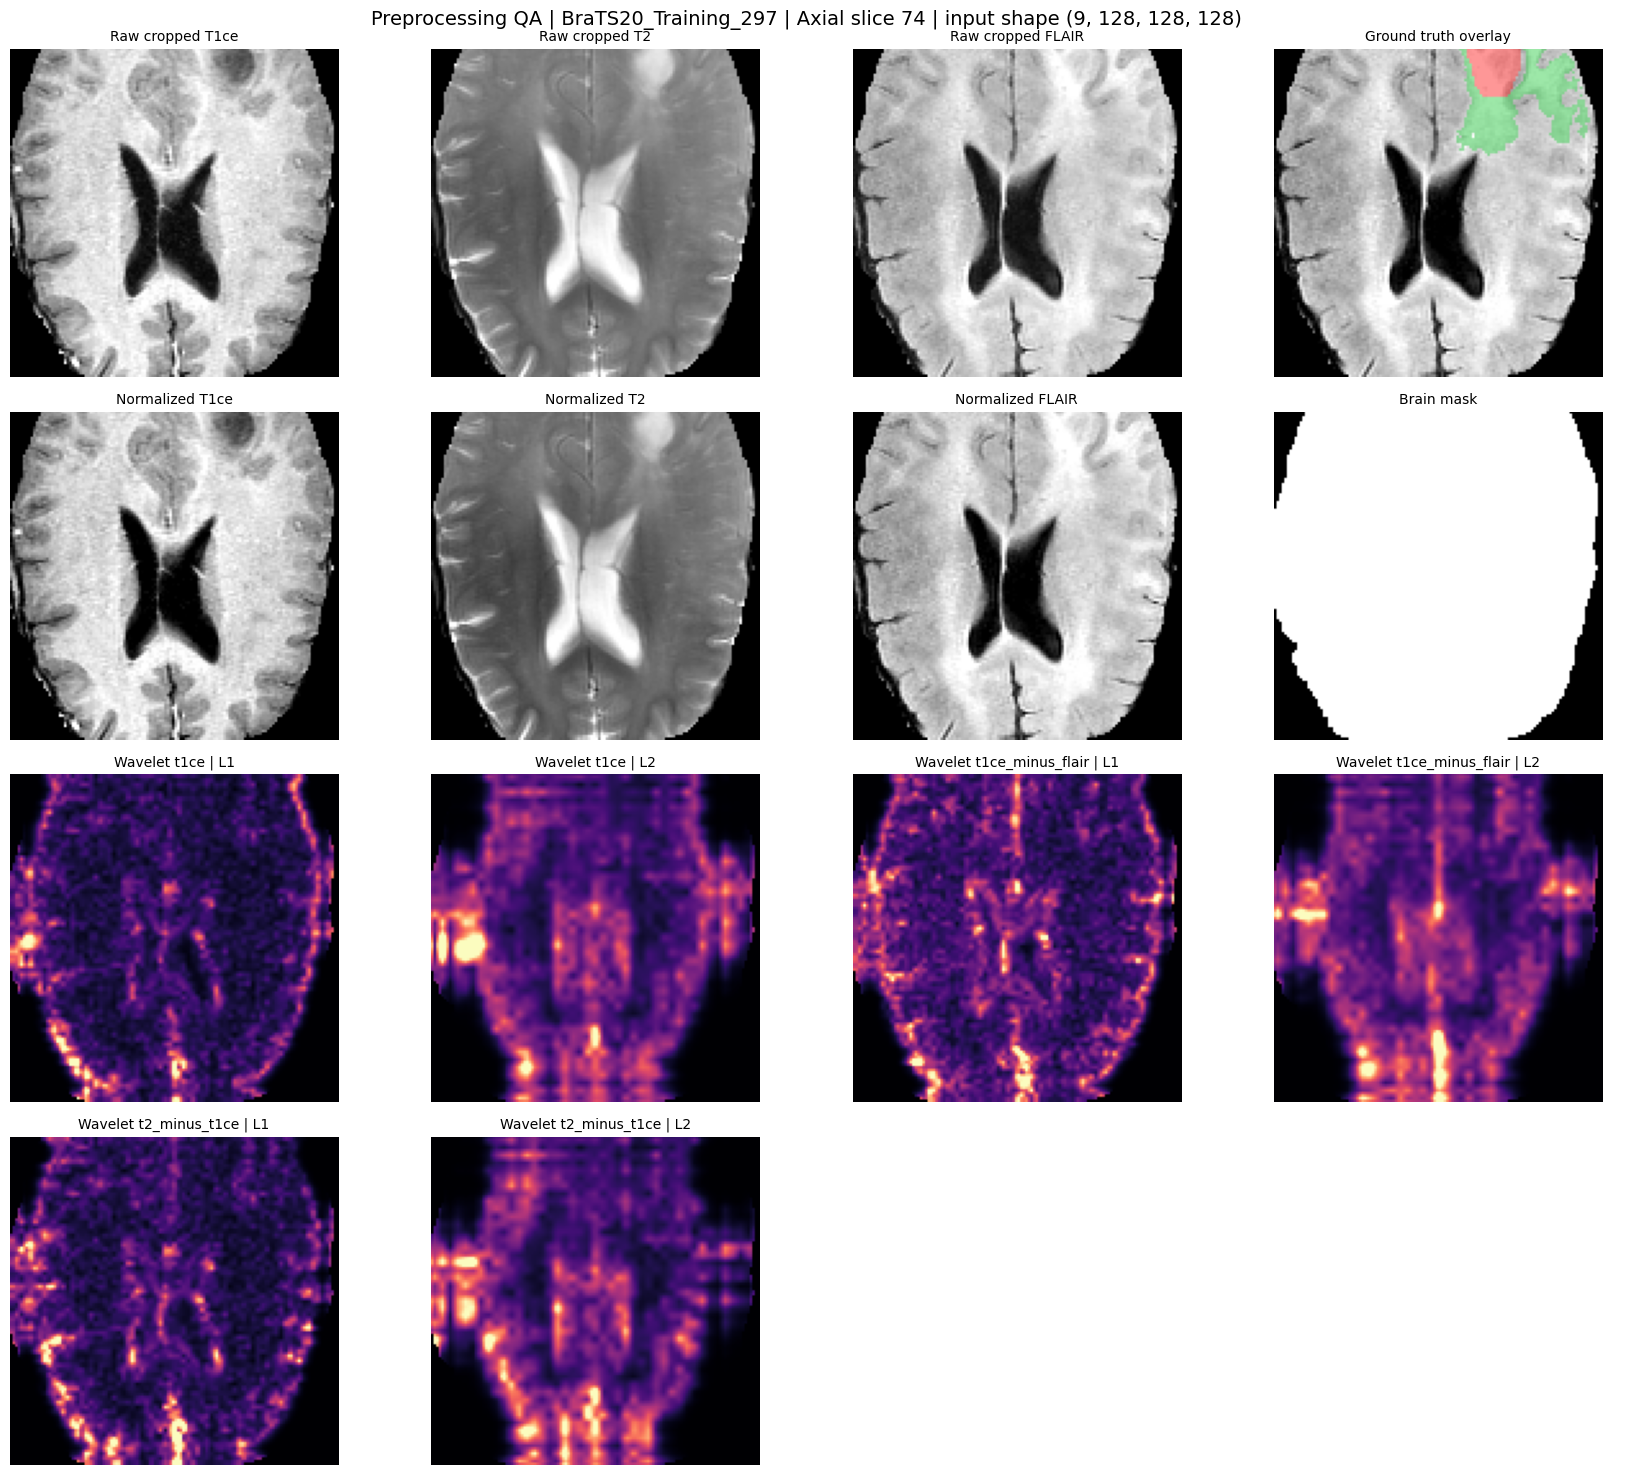

Final model input shape: (9, 128, 128, 128)
Mask labels: [0 1 2]
Wavelet channel range:
  channel 3: min=0.0000, max=1.0000, mean=0.1455
  channel 4: min=0.0000, max=1.0000, mean=0.1637
  channel 5: min=0.0000, max=1.0000, mean=0.1788
  channel 6: min=0.0000, max=1.0000, mean=0.1664
  channel 7: min=0.0000, max=1.0000, mean=0.1505
  channel 8: min=0.0000, max=1.0000, mean=0.1476


In [12]:

# Cell 11 - Preprocessing quality visualization
def load_raw_cropped_modalities_for_preview(case: Dict[str, str]):
    """Load and center-crop raw modalities before intensity normalization."""
    arrays = {}
    imgs = {}
    for modality in INPUT_MODALITIES:
        arr, img = load_nifti(case[modality], dtype=np.float32)
        arrays[modality] = arr
        imgs[modality] = img

    ref_img = imgs[INPUT_MODALITIES[0]]
    spacing = tuple(float(x) for x in ref_img.header.get_zooms()[:3])

    raw_cropped = {}
    for modality, arr in arrays.items():
        arr = resample_if_needed(arr, spacing, order=1)
        raw_cropped[modality] = center_crop_pad_3d(arr, PATCH_SIZE, pad_value=0)
    return raw_cropped


def show_volume_slice(ax, volume: np.ndarray, axis: int, index: int, title: str, cmap="gray"):
    sl = np.rot90(take_slice(volume, axis, index))
    if cmap == "gray":
        ax.imshow(normalize_slice(sl), cmap="gray")
    else:
        ax.imshow(sl, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.axis("off")


def visualize_preprocessing_case(case: Dict[str, str], axis: int = 2, log_to_wandb: bool = True):
    """
    Visual QA for one BraTS case.

    axis:
      0 = sagittal
      1 = coronal
      2 = axial
    """
    item = preprocess_case(case, require_mask=True)
    raw = load_raw_cropped_modalities_for_preview(case)
    seg = item["mask"]
    flair = item["image"][2]
    slice_idx = choose_best_slice(seg, axis)

    wavelet_names = []
    for source_name in WAVELET_SOURCE_NAMES:
        for level in range(1, WAVELET_LEVEL + 1):
            wavelet_names.append(f"{source_name} | L{level}")

    fig, axes = plt.subplots(4, 4, figsize=(17, 15))
    axes = axes.ravel()

    # Row 1: raw cropped MRI + ground-truth overlay.
    show_volume_slice(axes[0], raw["t1ce"], axis, slice_idx, "Raw cropped T1ce")
    show_volume_slice(axes[1], raw["t2"], axis, slice_idx, "Raw cropped T2")
    show_volume_slice(axes[2], raw["flair"], axis, slice_idx, "Raw cropped FLAIR")
    gray = np.rot90(take_slice(flair, axis, slice_idx))
    gt_slice = np.rot90(take_slice(seg, axis, slice_idx))
    axes[3].imshow(overlay_seg_on_gray(gray, gt_slice))
    axes[3].set_title("Ground truth overlay", fontsize=10)
    axes[3].axis("off")

    # Row 2: normalized MRI channels + brain mask.
    show_volume_slice(axes[4], item["image"][0], axis, slice_idx, "Normalized T1ce")
    show_volume_slice(axes[5], item["image"][1], axis, slice_idx, "Normalized T2")
    show_volume_slice(axes[6], item["image"][2], axis, slice_idx, "Normalized FLAIR")
    show_volume_slice(axes[7], item["brain_mask"].astype(np.float32), axis, slice_idx, "Brain mask")

    # Rows 3-4: six wavelet maps. Empty slots are hidden.
    for offset, name in enumerate(wavelet_names):
        channel_index = NUM_MRI_CHANNELS + offset
        show_volume_slice(
            axes[8 + offset],
            item["image"][channel_index],
            axis,
            slice_idx,
            f"Wavelet {name}",
            cmap="magma",
        )

    for ax in axes[8 + len(wavelet_names):]:
        ax.axis("off")

    axis_name = {0: "Sagittal", 1: "Coronal", 2: "Axial"}[axis]
    fig.suptitle(
        f"Preprocessing QA | {item['case_id']} | {axis_name} slice {slice_idx} | input shape {item['image'].shape}",
        fontsize=14,
    )
    fig.tight_layout()

    if log_to_wandb:
        try:
            wandb.log({"preprocessing/quality_check": wandb.Image(fig)})
        except Exception as exc:
            print("Could not log preprocessing figure to W&B:", exc)

    return fig, item


# Run one visual QA example before training.
# Change val_cases[0] to train_cases[i] or val_cases[i] to inspect more cases.
fig, preprocessing_debug_item = visualize_preprocessing_case(val_cases[0], axis=2, log_to_wandb=True)
plt.show()
print("Final model input shape:", preprocessing_debug_item["image"].shape)
print("Mask labels:", np.unique(preprocessing_debug_item["mask"]))
print("Wavelet channel range:")
for i in range(NUM_WAVELET_CHANNELS):
    ch = preprocessing_debug_item["image"][NUM_MRI_CHANNELS + i]
    print(f"  channel {NUM_MRI_CHANNELS + i}: min={ch.min():.4f}, max={ch.max():.4f}, mean={ch.mean():.4f}")


In [13]:
# Cell 12 - Training and validation loops
def train_one_epoch(model, loader, epoch: int):
    model.train()
    total_loss = 0.0
    n_batches = 0
    metric_lists = {"dice_wt": [], "dice_tc": [], "dice_et": []}
    start = time.time()

    pbar = tqdm(loader, desc=f"Train epoch {epoch}")
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=(USE_AMP and torch.cuda.is_available())):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        if GRAD_CLIP_NORM is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.detach().cpu())
        n_batches += 1

        # Train Dice is for monitoring only. Best checkpoint is still selected by validation Dice/loss.
        pred_labels = logits_to_brats_labels(logits.detach()).cpu().numpy()
        target_labels = masks.detach().cpu().numpy()
        for sample_idx in range(pred_labels.shape[0]):
            batch_metrics = compute_case_metrics(
                pred_labels[sample_idx],
                target_labels[sample_idx],
                compute_hd95=False,
            )
            for key in metric_lists:
                metric_lists[key].append(batch_metrics[key])

        running_loss = total_loss / max(1, n_batches)
        running_mean_dice = safe_mean([
            safe_mean(metric_lists["dice_wt"]),
            safe_mean(metric_lists["dice_tc"]),
            safe_mean(metric_lists["dice_et"]),
        ])
        pbar.set_postfix(loss=running_loss, dice=running_mean_dice)

    result = {
        "loss": total_loss / max(1, n_batches),
        "dice_wt": safe_mean(metric_lists["dice_wt"]),
        "dice_tc": safe_mean(metric_lists["dice_tc"]),
        "dice_et": safe_mean(metric_lists["dice_et"]),
        "seconds": time.time() - start,
    }
    result["mean_dice"] = safe_mean([result["dice_wt"], result["dice_tc"], result["dice_et"]])
    return result


@torch.no_grad()
def validate(model, loader, epoch: int):
    model.eval()
    losses = []
    metric_lists = {"dice_wt": [], "dice_tc": [], "dice_et": []}
    if COMPUTE_HD95:
        metric_lists.update({"hd95_wt": [], "hd95_tc": [], "hd95_et": []})

    start = time.time()
    for batch in tqdm(loader, desc=f"Val epoch {epoch}"):
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        with autocast(enabled=(USE_AMP and torch.cuda.is_available())):
            logits = model(images)
            loss = criterion(logits, masks)

        losses.append(float(loss.detach().cpu()))
        pred_labels = logits_to_brats_labels(logits).cpu().numpy()[0]
        target_labels = masks.cpu().numpy()[0]
        case_metrics = compute_case_metrics(pred_labels, target_labels, compute_hd95=COMPUTE_HD95)
        for k, v in case_metrics.items():
            if k in metric_lists:
                metric_lists[k].append(v)

    result = {
        "loss": safe_mean(losses),
        "dice_wt": safe_mean(metric_lists["dice_wt"]),
        "dice_tc": safe_mean(metric_lists["dice_tc"]),
        "dice_et": safe_mean(metric_lists["dice_et"]),
        "seconds": time.time() - start,
    }
    result["mean_dice"] = safe_mean([result["dice_wt"], result["dice_tc"], result["dice_et"]])

    if COMPUTE_HD95:
        result.update({
            "hd95_wt": safe_mean(metric_lists["hd95_wt"]),
            "hd95_tc": safe_mean(metric_lists["hd95_tc"]),
            "hd95_et": safe_mean(metric_lists["hd95_et"]),
        })
    return result


@torch.no_grad()
def log_validation_overlay(model, case: Dict[str, str], epoch: int):
    model.eval()
    item = preprocess_case(case, require_mask=True)
    image = torch.from_numpy(item["image"][None]).float().to(device)
    logits = model(image)
    pred = logits_to_brats_labels(logits).cpu().numpy()[0]
    fig = make_overlay_figure(item["flair"], pred, item["mask"], title=f"{item['case_id']} | epoch {epoch}")
    wandb.log({"val/sample_overlay": wandb.Image(fig), "epoch": epoch})
    plt.close(fig)


In [14]:
# Cell 13 - Run training
history = []
best_score = -float("inf")
best_epoch = -1
start_epoch = 1

if RESUME_FROM_LAST and LAST_CHECKPOINT_PATH.exists():
    print(f"Found last checkpoint: {LAST_CHECKPOINT_PATH}")
    resume_ckpt = torch.load(LAST_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(resume_ckpt["model_state_dict"])
    optimizer.load_state_dict(resume_ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(resume_ckpt["scheduler_state_dict"])
    if resume_ckpt.get("scaler_state_dict") is not None:
        scaler.load_state_dict(resume_ckpt["scaler_state_dict"])
    history = resume_ckpt.get("history", [])
    best_score = resume_ckpt.get("best_score", best_score)
    best_epoch = resume_ckpt.get("best_epoch", resume_ckpt.get("epoch", best_epoch))
    start_epoch = int(resume_ckpt.get("epoch", 0)) + 1
    print(f"Resuming from epoch {start_epoch}/{EPOCHS}. Best epoch so far: {best_epoch}, best score: {best_score:.5f}")

if start_epoch > EPOCHS:
    print(f"Checkpoint already reached epoch {start_epoch - 1}. Increase EPOCHS or delete {LAST_CHECKPOINT_PATH} to restart.")

for epoch in range(start_epoch, EPOCHS + 1):
    train_result = train_one_epoch(model, train_loader, epoch)
    val_result = validate(model, val_loader, epoch)
    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "train_dice_wt": train_result["dice_wt"],
        "train_dice_tc": train_result["dice_tc"],
        "train_dice_et": train_result["dice_et"],
        "train_mean_dice": train_result["mean_dice"],
        "val_loss": val_result["loss"],
        "val_dice_wt": val_result["dice_wt"],
        "val_dice_tc": val_result["dice_tc"],
        "val_dice_et": val_result["dice_et"],
        "val_mean_dice": val_result["mean_dice"],
        "delta_vs_30ep_baseline": val_result["mean_dice"] - BASELINE_30EP_VAL_MEAN_DICE,
        "hit_et_target": float(val_result["dice_et"] >= TARGET_VAL_DICE_ET),
        "lr": scheduler.get_last_lr()[0],
        "train_seconds": train_result["seconds"],
        "val_seconds": val_result["seconds"],
    }
    if COMPUTE_HD95:
        row.update({
            "val_hd95_wt": val_result.get("hd95_wt", np.nan),
            "val_hd95_tc": val_result.get("hd95_tc", np.nan),
            "val_hd95_et": val_result.get("hd95_et", np.nan),
        })
    history.append(row)

    print("\n" + "=" * 120)
    print(f"Epoch {epoch:03d}/{EPOCHS} summary")
    print("=" * 120)
    print(pd.DataFrame([row]).round(5).to_string(index=False))
    print("=" * 120)

    wandb.log({
        "epoch": epoch,
        "train/loss": row["train_loss"],
        "train/dice_wt": row["train_dice_wt"],
        "train/dice_tc": row["train_dice_tc"],
        "train/dice_et": row["train_dice_et"],
        "train/mean_dice": row["train_mean_dice"],
        "val/loss": row["val_loss"],
        "val/dice_wt": row["val_dice_wt"],
        "val/dice_tc": row["val_dice_tc"],
        "val/dice_et": row["val_dice_et"],
        "val/mean_dice": row["val_mean_dice"],
        "val/delta_vs_30ep_baseline": row["delta_vs_30ep_baseline"],
        "val/hit_et_target": row["hit_et_target"],
        "train/lr": row["lr"],
        "time/train_seconds": row["train_seconds"],
        "time/val_seconds": row["val_seconds"],
    })

    score = row["val_mean_dice"]
    if not np.isfinite(score):
        score = -row["val_loss"]

    if score > best_score:
        best_score = score
        best_epoch = epoch
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_score": best_score,
            "best_epoch": best_epoch,
            "config": CONFIG,
            "history": history,
        }, CHECKPOINT_PATH)
        wandb.save(str(CHECKPOINT_PATH))
        print(f"Saved best checkpoint: epoch={epoch}, score={best_score:.5f}")

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "best_score": best_score,
        "best_epoch": best_epoch,
        "config": CONFIG,
        "history": history,
    }, LAST_CHECKPOINT_PATH)
    wandb.save(str(LAST_CHECKPOINT_PATH))
    print(f"Saved last checkpoint: {LAST_CHECKPOINT_PATH}")

    if epoch == 1 or epoch % VIS_EVERY_N_EPOCHS == 0:
        log_validation_overlay(model, val_cases[0], epoch)

    pd.DataFrame(history).to_csv(SUMMARY_CSV_PATH, index=False)

print(f"Training complete. Best epoch: {best_epoch}, best score: {best_score:.5f}")
wandb.save(str(SUMMARY_CSV_PATH))

Val epoch 1: 100%|██████████| 73/73 [03:38<00:00,  2.99s/it]
wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.



Epoch 001/100 summary
 epoch  train_loss  train_dice_wt  train_dice_tc  train_dice_et  train_mean_dice  val_loss  val_dice_wt  val_dice_tc  val_dice_et  val_mean_dice  delta_vs_30ep_baseline  hit_et_target     lr  train_seconds  val_seconds
     1     0.78858        0.18129         0.0835        0.04312          0.10264   0.69422      0.30303      0.14723      0.07729        0.17585                -0.64968            0.0 0.0001      282.67771    218.08123
Saved best checkpoint: epoch=1, score=0.17585


wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


Saved last checkpoint: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\outputs\last_latupnet_wavelet_region3_sigmoid_priority1.pth


Val epoch 2: 100%|██████████| 73/73 [00:21<00:00,  3.42it/s]


...

Val epoch 100: 100%|██████████| 73/73 [00:20<00:00,  3.52it/s]



Epoch 100/100 summary
 epoch  train_loss  train_dice_wt  train_dice_tc  train_dice_et  train_mean_dice  val_loss  val_dice_wt  val_dice_tc  val_dice_et  val_mean_dice  delta_vs_30ep_baseline  hit_et_target  lr  train_seconds  val_seconds
   100     0.20052        0.90171        0.85646        0.73647          0.83155   0.17445      0.91546      0.87551      0.74385        0.84494                 0.01941            1.0 0.0      242.34933     20.74513
Saved last checkpoint: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\outputs\last_latupnet_wavelet_region3_sigmoid_priority1.pth


wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


Training complete. Best epoch: 77, best score: 0.84636


['c:\\Users\\ezycloudx-admin\\Downloads\\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\\wandb\\run-20260709_001904-ucis2xwz\\files\\outputs\\training_summary_region3_sigmoid_priority1.csv']

## Inference Sample

This section loads the best checkpoint, predicts a few validation cases, saves `.nii.gz` predictions, and logs overlay images to W&B.

Prediction label mapping:

```text
model channel 0 -> BraTS 0 background
model channel 1 -> BraTS 1 NCR/NET
model channel 2 -> BraTS 2 ED
model channel 3 -> BraTS 4 ET
```


In [15]:
# Cell 14 - Inference samples and prediction saving
@torch.no_grad()
def predict_case_and_save(model, case: Dict[str, str], output_dir: Path):
    item = preprocess_case(case, require_mask=True)
    image = torch.from_numpy(item["image"][None]).float().to(device)

    start = time.time()
    with autocast(enabled=(USE_AMP and torch.cuda.is_available())):
        logits = model(image)
    infer_ms = (time.time() - start) * 1000.0

    pred_crop = logits_to_brats_labels(logits).cpu().numpy()[0].astype(np.uint8)
    pred_full = inverse_center_crop_pad_3d(pred_crop, item["crop_meta"], pad_value=0).astype(np.uint8)

    out_path = output_dir / f"pred_{item['case_id']}.nii.gz"
    nib.save(nib.Nifti1Image(pred_full, item["affine"]), str(out_path))

    fig = make_overlay_figure(item["flair"], pred_crop, item["mask"], title=f"{item['case_id']} | {infer_ms:.1f} ms")
    wandb.log({
        f"prediction/{item['case_id']}": wandb.Image(fig),
        "inference/time_ms_per_case": infer_ms,
    })
    plt.close(fig)

    pred_regions = region_masks_from_labels(pred_crop)
    voxel_counts = {region: int(mask.sum()) for region, mask in pred_regions.items()}
    return {
        "case_id": item["case_id"],
        "prediction_path": str(out_path),
        "inference_ms": infer_ms,
        **{f"voxels_{k.lower()}": v for k, v in voxel_counts.items()},
    }


checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

prediction_rows = []
for case in val_cases[:NUM_SAMPLE_PREDICTIONS]:
    prediction_rows.append(predict_case_and_save(model, case, PRED_DIR))

pred_df = pd.DataFrame(prediction_rows)
display(pred_df)
pred_df.to_csv(WORK_DIR / "sample_prediction_summary.csv", index=False)
wandb.save(str(WORK_DIR / "sample_prediction_summary.csv"))
for path in PRED_DIR.glob("*.nii.gz"):
    wandb.save(str(path))


,case_id,prediction_path,inference_ms,voxels_wt,voxels_tc,voxels_et
0,BraTS20_Training_297,C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tu...,6.792784,54506,20537,133
1,BraTS20_Training_247,C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tu...,5.000830,94920,64381,41226
2,BraTS20_Training_179,C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tu...,5.002737,68053,39733,35052


wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.
wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.
wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.
wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


In [16]:

# Cell 15- Final evaluation with HD95
@torch.no_grad()
def final_evaluate_with_hd95(model, loader):
    model.eval()
    rows = []
    start = time.time()

    for batch in tqdm(loader, desc="Final HD95 evaluation"):
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)
        case_id = batch["case_id"][0] if isinstance(batch["case_id"], (list, tuple)) else batch["case_id"]

        with autocast(enabled=(USE_AMP and torch.cuda.is_available())):
            logits = model(images)
            loss = criterion(logits, masks)

        pred_labels = logits_to_brats_labels(logits).cpu().numpy()[0]
        target_labels = masks.cpu().numpy()[0]
        metrics = compute_case_metrics(
            pred_labels,
            target_labels,
            spacing=TARGET_SPACING,
            compute_hd95=True,
        )
        metrics["case_id"] = case_id
        metrics["loss"] = float(loss.detach().cpu())
        rows.append(metrics)

    df = pd.DataFrame(rows)
    summary = {}
    metric_cols = [c for c in df.columns if c not in ["case_id"]]
    for col in metric_cols:
        finite_values = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        summary[f"{col}_mean"] = float(finite_values.mean()) if len(finite_values) else float("nan")
        summary[f"{col}_std"] = float(finite_values.std()) if len(finite_values) else float("nan")

    summary["eval_seconds"] = time.time() - start
    return df, summary


checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

hd95_df, hd95_summary = final_evaluate_with_hd95(model, val_loader)
HD95_REPORT_PATH = WORK_DIR / f"final_hd95_report_{EXPERIMENT_TAG}.csv"
HD95_SUMMARY_PATH = WORK_DIR / f"final_hd95_summary_{EXPERIMENT_TAG}.csv"

hd95_df.to_csv(HD95_REPORT_PATH, index=False)
pd.DataFrame([hd95_summary]).to_csv(HD95_SUMMARY_PATH, index=False)

print("=" * 90)
print("FINAL EVALUATION WITH HD95")
print("=" * 90)
print(f"Cases: {len(hd95_df)}")
print(f"Dice WT:  {hd95_summary['dice_wt_mean']:.5f} ± {hd95_summary['dice_wt_std']:.5f}")
print(f"Dice TC:  {hd95_summary['dice_tc_mean']:.5f} ± {hd95_summary['dice_tc_std']:.5f}")
print(f"Dice ET:  {hd95_summary['dice_et_mean']:.5f} ± {hd95_summary['dice_et_std']:.5f}")
print(f"HD95 WT:  {hd95_summary['hd95_wt_mean']:.5f} ± {hd95_summary['hd95_wt_std']:.5f} mm")
print(f"HD95 TC:  {hd95_summary['hd95_tc_mean']:.5f} ± {hd95_summary['hd95_tc_std']:.5f} mm")
print(f"HD95 ET:  {hd95_summary['hd95_et_mean']:.5f} ± {hd95_summary['hd95_et_std']:.5f} mm")
print(f"Eval time: {hd95_summary['eval_seconds'] / 60:.2f} minutes")
print(f"Saved: {HD95_REPORT_PATH}")
print(f"Saved: {HD95_SUMMARY_PATH}")
print("=" * 90)

display(hd95_df.head())

wandb.log({
    "final/dice_wt_mean": hd95_summary["dice_wt_mean"],
    "final/dice_tc_mean": hd95_summary["dice_tc_mean"],
    "final/dice_et_mean": hd95_summary["dice_et_mean"],
    "final/hd95_wt_mean": hd95_summary["hd95_wt_mean"],
    "final/hd95_tc_mean": hd95_summary["hd95_tc_mean"],
    "final/hd95_et_mean": hd95_summary["hd95_et_mean"],
    "final/hd95_eval_seconds": hd95_summary["eval_seconds"],
})
for key, value in hd95_summary.items():
    wandb.summary[f"final_hd95/{key}"] = value
wandb.save(str(HD95_REPORT_PATH))
wandb.save(str(HD95_SUMMARY_PATH))

Final HD95 evaluation: 100%|██████████| 73/73 [01:32<00:00,  1.26s/it]

FINAL EVALUATION WITH HD95
Cases: 73
Dice WT:  0.91506 ± 0.05448
Dice TC:  0.87739 ± 0.12355
Dice ET:  0.74664 ± 0.25224
HD95 WT:  4.72348 ± 7.49062 mm
HD95 TC:  5.13343 ± 6.82429 mm
HD95 ET:  4.34006 ± 7.23896 mm
Eval time: 1.53 minutes
Saved: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\outputs\final_hd95_report_region3_sigmoid_priority1.csv
Saved: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\outputs\final_hd95_summary_region3_sigmoid_priority1.csv


,dice_wt,hd95_wt,dice_tc,hd95_tc,dice_et,hd95_et,case_id,loss
0,0.821589,11.575837,0.772655,5.385165,0.000000,inf,BraTS20_Training_297,0.530127
1,0.914145,5.385165,0.959120,1.732051,0.886094,1.414214,BraTS20_Training_247,0.085078
2,0.926313,3.464102,0.913566,3.316625,0.873171,3.162278,BraTS20_Training_179,0.100654
3,0.877940,4.123106,0.381183,16.155494,0.827100,2.236068,BraTS20_Training_267,0.304395
4,0.873344,4.242641,0.856755,4.898979,0.747610,2.236068,BraTS20_Training_035,0.185154


wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.
wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


['c:\\Users\\ezycloudx-admin\\Downloads\\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\\wandb\\run-20260709_001904-ucis2xwz\\files\\outputs\\final_hd95_summary_region3_sigmoid_priority1.csv']

In [17]:
# Cell 16 - Final report summary
history_df = pd.DataFrame(history)
history_df.to_csv(SUMMARY_CSV_PATH, index=False)

if history_df["val_mean_dice"].notna().any():
    best_row = history_df.loc[history_df["val_mean_dice"].idxmax()]
else:
    best_row = history_df.loc[history_df["val_loss"].idxmin()]

print("=" * 70)
print("FINAL REPORT: LATUPNet + 3D Wavelet Preprocessing")
print("=" * 70)
print(f"Best epoch: {int(best_row['epoch'])}")
print(f"Best validation loss: {best_row['val_loss']:.5f}")
print(f"Dice WT: {best_row['val_dice_wt']:.5f}")
print(f"Dice TC: {best_row['val_dice_tc']:.5f}")
print(f"Dice ET: {best_row['val_dice_et']:.5f}")
print(f"Mean Dice: {best_row['val_mean_dice']:.5f}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Training summary: {SUMMARY_CSV_PATH}")
print(f"Sample predictions: {PRED_DIR}")
print("=" * 70)

display(history_df.tail())
wandb.summary["best_epoch"] = int(best_row["epoch"])
wandb.summary["best_val_loss"] = float(best_row["val_loss"])
wandb.summary["best_val_dice_wt"] = float(best_row["val_dice_wt"])
wandb.summary["best_val_dice_tc"] = float(best_row["val_dice_tc"])
wandb.summary["best_val_dice_et"] = float(best_row["val_dice_et"])
wandb.summary["best_val_mean_dice"] = float(best_row["val_mean_dice"])
wandb.finish()


FINAL REPORT: LATUPNet + 3D Wavelet Preprocessing
Best epoch: 77
Best validation loss: 0.17353
Dice WT: 0.91506
Dice TC: 0.87739
Dice ET: 0.74664
Mean Dice: 0.84636
Checkpoint: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\outputs\best_latupnet_wavelet_region3_sigmoid_priority1.pth
Training summary: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\outputs\training_summary_region3_sigmoid_priority1.csv
Sample predictions: C:\Users\ezycloudx-admin\Downloads\3D-Brain-Tumor-Reconstruction-and-Segmentation-main\outputs\sample_predictions_region3_sigmoid_priority1


,epoch,train_loss,train_dice_wt,train_dice_tc,train_dice_et,train_mean_dice,val_loss,val_dice_wt,val_dice_tc,val_dice_et,val_mean_dice,delta_vs_30ep_baseline,hit_et_target,lr,train_seconds,val_seconds
95,96,0.197902,0.900748,0.856717,0.742612,0.833359,0.173723,0.915593,0.875871,0.745533,0.845666,0.020136,1.0,0.000001,241.876493,20.765751
96,97,0.201396,0.902336,0.852454,0.740850,0.831880,0.174109,0.915364,0.876005,0.744391,0.845254,0.019724,1.0,0.000001,241.065520,20.726031
97,98,0.199423,0.901123,0.859318,0.738264,0.832902,0.174388,0.915576,0.875929,0.743395,0.844967,0.019437,1.0,0.000001,243.661325,20.919140
98,99,0.203045,0.900396,0.851264,0.735044,0.828902,0.174473,0.915491,0.875567,0.743790,0.844950,0.019420,1.0,0.000001,244.514483,20.826164
99,100,0.200520,0.901711,0.856456,0.736472,0.831546,0.174446,0.915461,0.875509,0.743852,0.844941,0.019411,1.0,0.000001,242.349325,20.745128


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██
final/dice_et_mean,▁
final/dice_tc_mean,▁
final/dice_wt_mean,▁
final/hd95_et_mean,▁
final/hd95_eval_seconds,▁
final/hd95_tc_mean,▁
final/hd95_wt_mean,▁
inference/time_ms_per_case,█▁▁
time/train_seconds,█▂▁▁▁▃▁▁▁▁▁▃▃▃▃▂▃▃▃▂▂▃▃▃▃▃▃▃▃▃▃▃▃▃▂▁▁▁▁▁
+14,...
